# Per-MoA Retrieval Analysis

Compare which MoAs are significantly retrieved by each model (best postprocessing config).
Venn diagrams, waterfall plots, heatmaps, and pairwise scatters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from matplotlib.lines import Line2D
from itertools import combinations
from functools import reduce
import os

os.makedirs("../figures", exist_ok=True)

MAP_PER_GROUP_DIR = "../results/map_per_group"

# Best postprocessing config per model (from visualize_postprocessing.ipynb Pareto analysis).
# TODO: finalize deepprofiler best config once A549 results are available.
BEST_CONFIGS = {
    "cellprofiler":       {"agg": "median", "fs": 1, "norm1": "mad_robustize", "norm2": "none"},
    "dino":               {"agg": "mean",   "fs": 1, "norm1": "PCA",           "norm2": "mad_robustize"},
    "subcell_mae_masked": {"agg": "median", "fs": 0, "norm1": "PCA",           "norm2": "standardize"}, # placeholder
    "deepprofiler":       {"agg": "mean",   "fs": 0, "norm1": "ZCAcor",        "norm2": "mad_robustize"},  # placeholder
}

MODELS = ["cellprofiler", "deepprofiler", "dino", "subcell_mae_masked"]
CELL_TYPES = ["U2OS", "A549"]

MODEL_LABELS = {
    "cellprofiler": "CellProfiler",
    "deepprofiler": "DeepProfiler",
    "dino": "DINO4Cells",
    "subcell_mae_masked": "SubCell MAE",
}

# Seaborn colorblind palette — consistent with visualize_postprocessing.ipynb
MODEL_COLORS = {
    "cellprofiler":       "#0173b2",  # blue
    "deepprofiler":       "#de8f05",  # amber
    "dino":               "#029e73",  # teal
    "subcell_mae_masked": "#d55e00",  # vermillion
}

In [2]:
def moa_filename(model, cell_type, cfg):
    stem = f"{cfg['agg']}__fs{cfg['fs']}__{cfg['norm1']}__{cfg['norm2']}"
    return f"{model}__{cell_type}__{stem}__moa.csv"

# Load per-MoA mAP results for each (model, cell_type)
moa_data = {}  # (model, cell_type) -> DataFrame
for model in MODELS:
    cfg = BEST_CONFIGS[model]
    for ct in CELL_TYPES:
        fname = moa_filename(model, ct, cfg)
        path = os.path.join(MAP_PER_GROUP_DIR, fname)
        if os.path.exists(path):
            df = pd.read_csv(path)
            assert "moas" in df.columns, f"{fname} is in old format (no moas column)"
            moa_data[(model, ct)] = df
            print(f"{MODEL_LABELS[model]:15s} {ct}: {len(df)} MoAs, "
                  f"{df['below_corrected_p'].sum()} significant (corrected p < 0.05)")
        else:
            print(f"MISSING: {fname}")

CellProfiler    U2OS: 77 MoAs, 23 significant (corrected p < 0.05)
CellProfiler    A549: 77 MoAs, 19 significant (corrected p < 0.05)
DeepProfiler    U2OS: 77 MoAs, 20 significant (corrected p < 0.05)
DeepProfiler    A549: 77 MoAs, 16 significant (corrected p < 0.05)
DINO4Cells      U2OS: 77 MoAs, 18 significant (corrected p < 0.05)
DINO4Cells      A549: 77 MoAs, 19 significant (corrected p < 0.05)
SubCell MAE     U2OS: 77 MoAs, 44 significant (corrected p < 0.05)
SubCell MAE     A549: 77 MoAs, 43 significant (corrected p < 0.05)


## Venn Diagram — SubCell MAE vs CellProfiler Significantly Retrieved MoAs

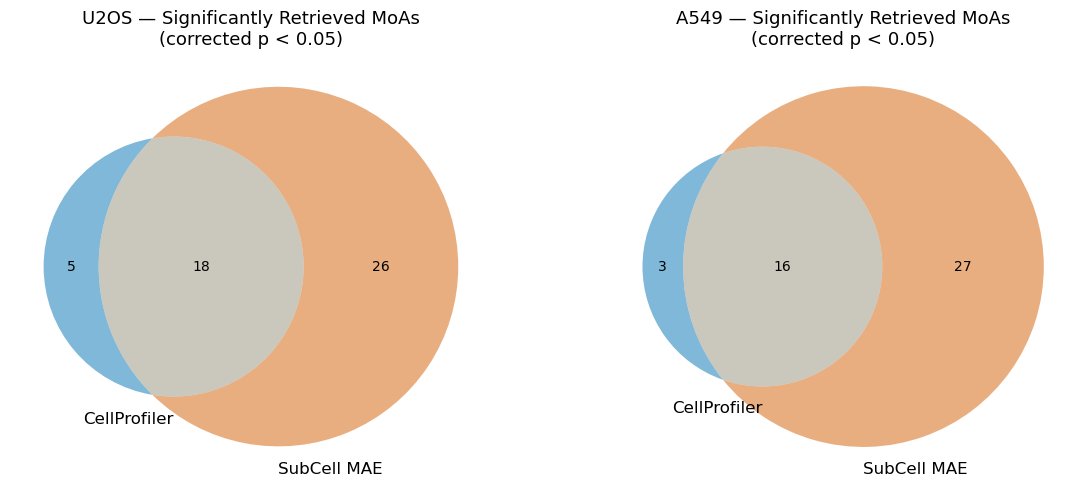

In [3]:
from matplotlib_venn import venn2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for col_idx, ct in enumerate(CELL_TYPES):
    ax = axes[col_idx]
    venn_models = ["cellprofiler", "subcell_mae_masked"]
    sig_sets = {}
    for model in venn_models:
        df = moa_data.get((model, ct))
        if df is not None:
            sig_sets[model] = set(df.loc[df["below_corrected_p"], "moas"])
        else:
            sig_sets[model] = set()

    v = venn2(
        [sig_sets[m] for m in venn_models],
        set_labels=[MODEL_LABELS[m] for m in venn_models],
        set_colors=[MODEL_COLORS[m] for m in venn_models],
        alpha=0.5,
        ax=ax,
    )
    ax.set_title(f"{ct} — Significantly Retrieved MoAs\n(corrected p < 0.05)", fontsize=13)

fig.tight_layout()
fig.savefig("../figures/moa_venn_diagram.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Waterfall Plots — Per-MoA mAP Ranked by Score

Each bar is one MoA, sorted by mAP. Bars colored by whether the corrected p-value < 0.05.

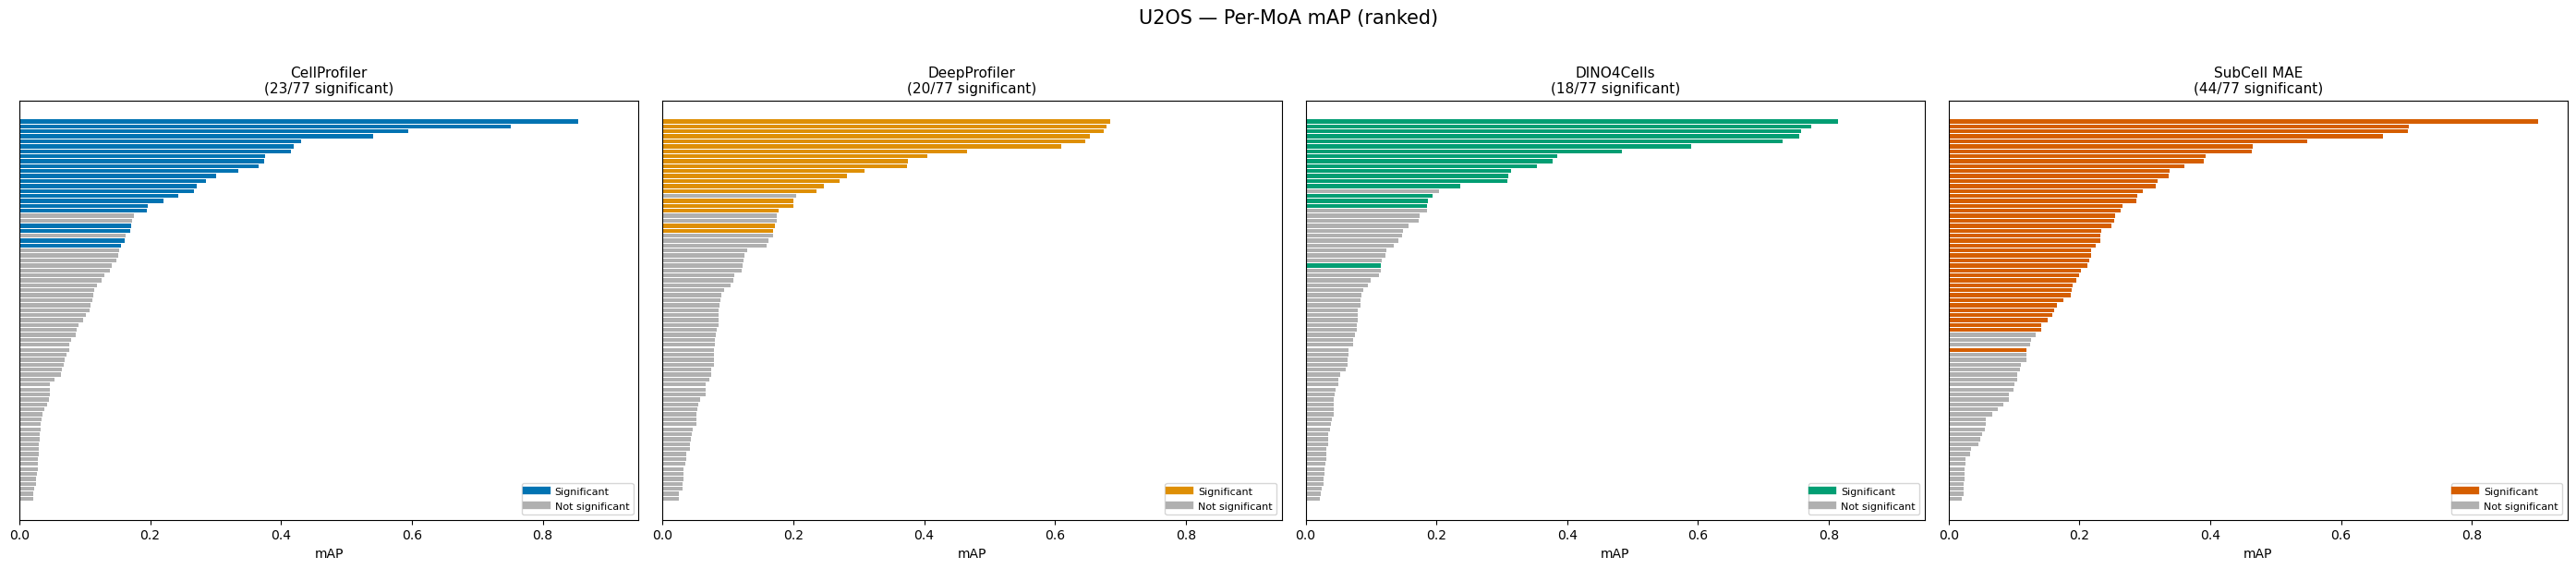

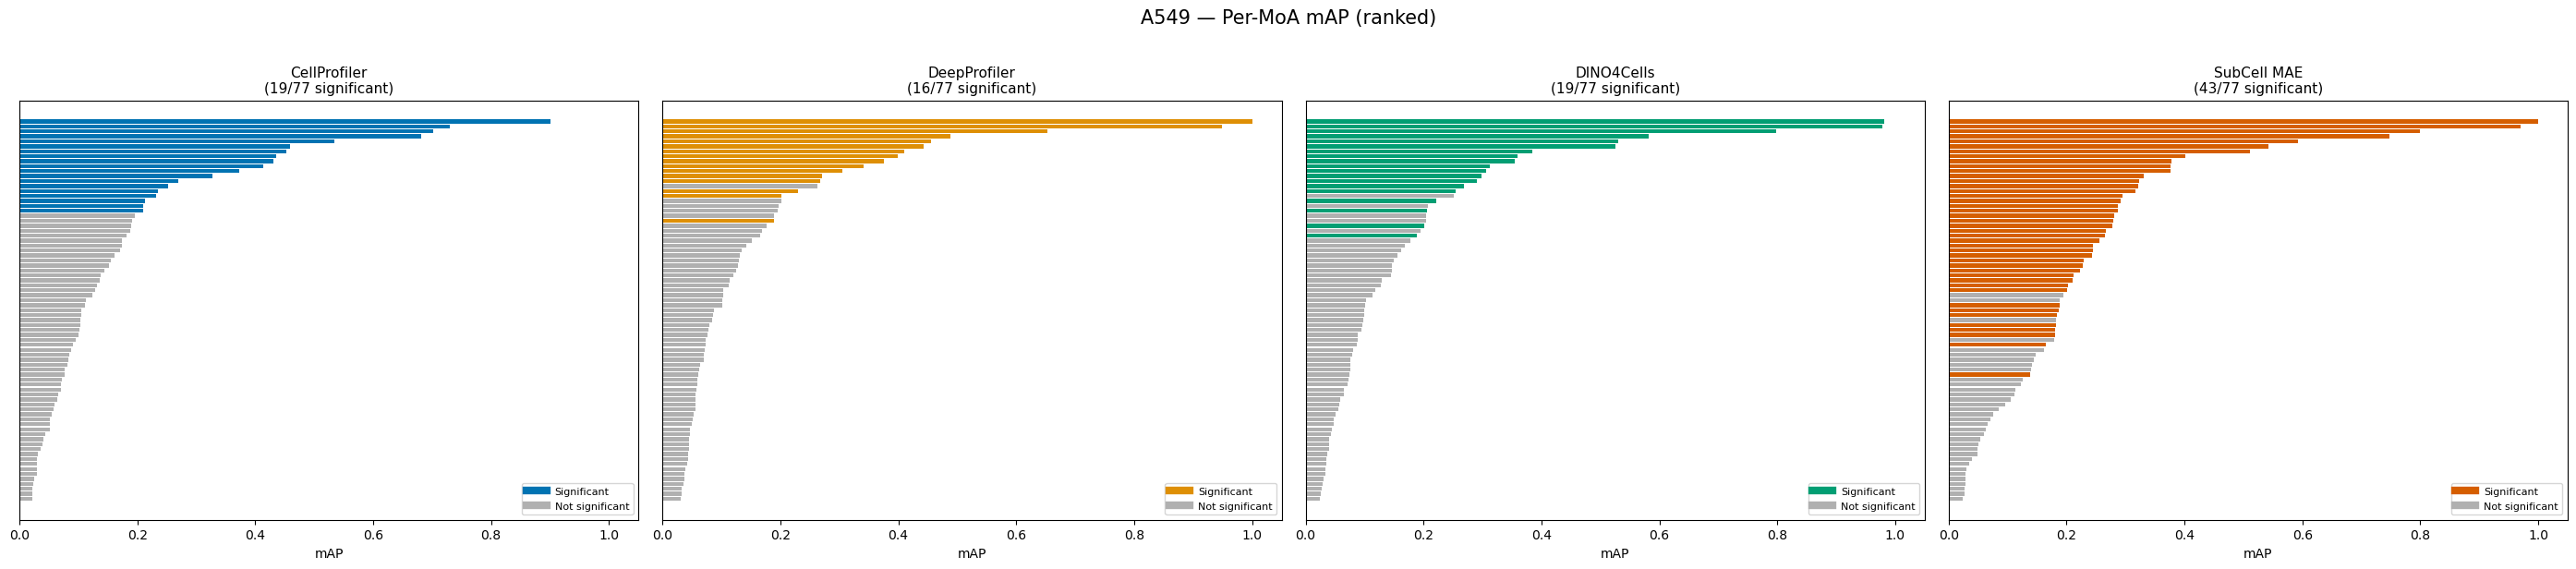

In [4]:
for ct in CELL_TYPES:
    fig, axes = plt.subplots(1, len(MODELS), figsize=(7 * len(MODELS), 6), sharey=True)
    fig.suptitle(f"{ct} — Per-MoA mAP (ranked)", fontsize=15, y=1.02)

    # Compute shared x-axis limit across all models for this cell type
    x_max = 0
    for model in MODELS:
        df = moa_data.get((model, ct))
        if df is not None:
            x_max = max(x_max, df["mean_average_precision"].max())
    x_max *= 1.05

    for i, model in enumerate(MODELS):
        ax = axes[i]
        df = moa_data.get((model, ct))
        if df is None:
            ax.set_visible(False)
            continue

        df_sorted = df.sort_values("mean_average_precision", ascending=True).reset_index(drop=True)
        colors = [MODEL_COLORS[model] if sig else "#b0b0b0"
                  for sig in df_sorted["below_corrected_p"]]

        ax.barh(range(len(df_sorted)), df_sorted["mean_average_precision"], color=colors,
                edgecolor="none", height=0.8)
        ax.set_xlabel("mAP")
        ax.set_xlim(0, x_max)
        if i == 0:
            ax.set_yticks(range(len(df_sorted)))
            ax.set_yticklabels(df_sorted["moas"], fontsize=6)
        else:
            ax.set_yticks([])
        n_sig = df["below_corrected_p"].sum()
        ax.set_title(f"{MODEL_LABELS[model]}\n({n_sig}/{len(df)} significant)", fontsize=11)

        handles = [
            Line2D([0], [0], color=MODEL_COLORS[model], lw=6, label="Significant"),
            Line2D([0], [0], color="#b0b0b0", lw=6, label="Not significant"),
        ]
        ax.legend(handles=handles, loc="lower right", fontsize=8)

    fig.tight_layout()
    fig.savefig(f"../figures/moa_waterfall_{ct}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

## Heatmap — Per-MoA mAP Across Models

Rows = MoAs (sorted by max mAP across models), columns = models.
Significance markers overlaid.

/tmp/ipykernel_123747/470606793.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


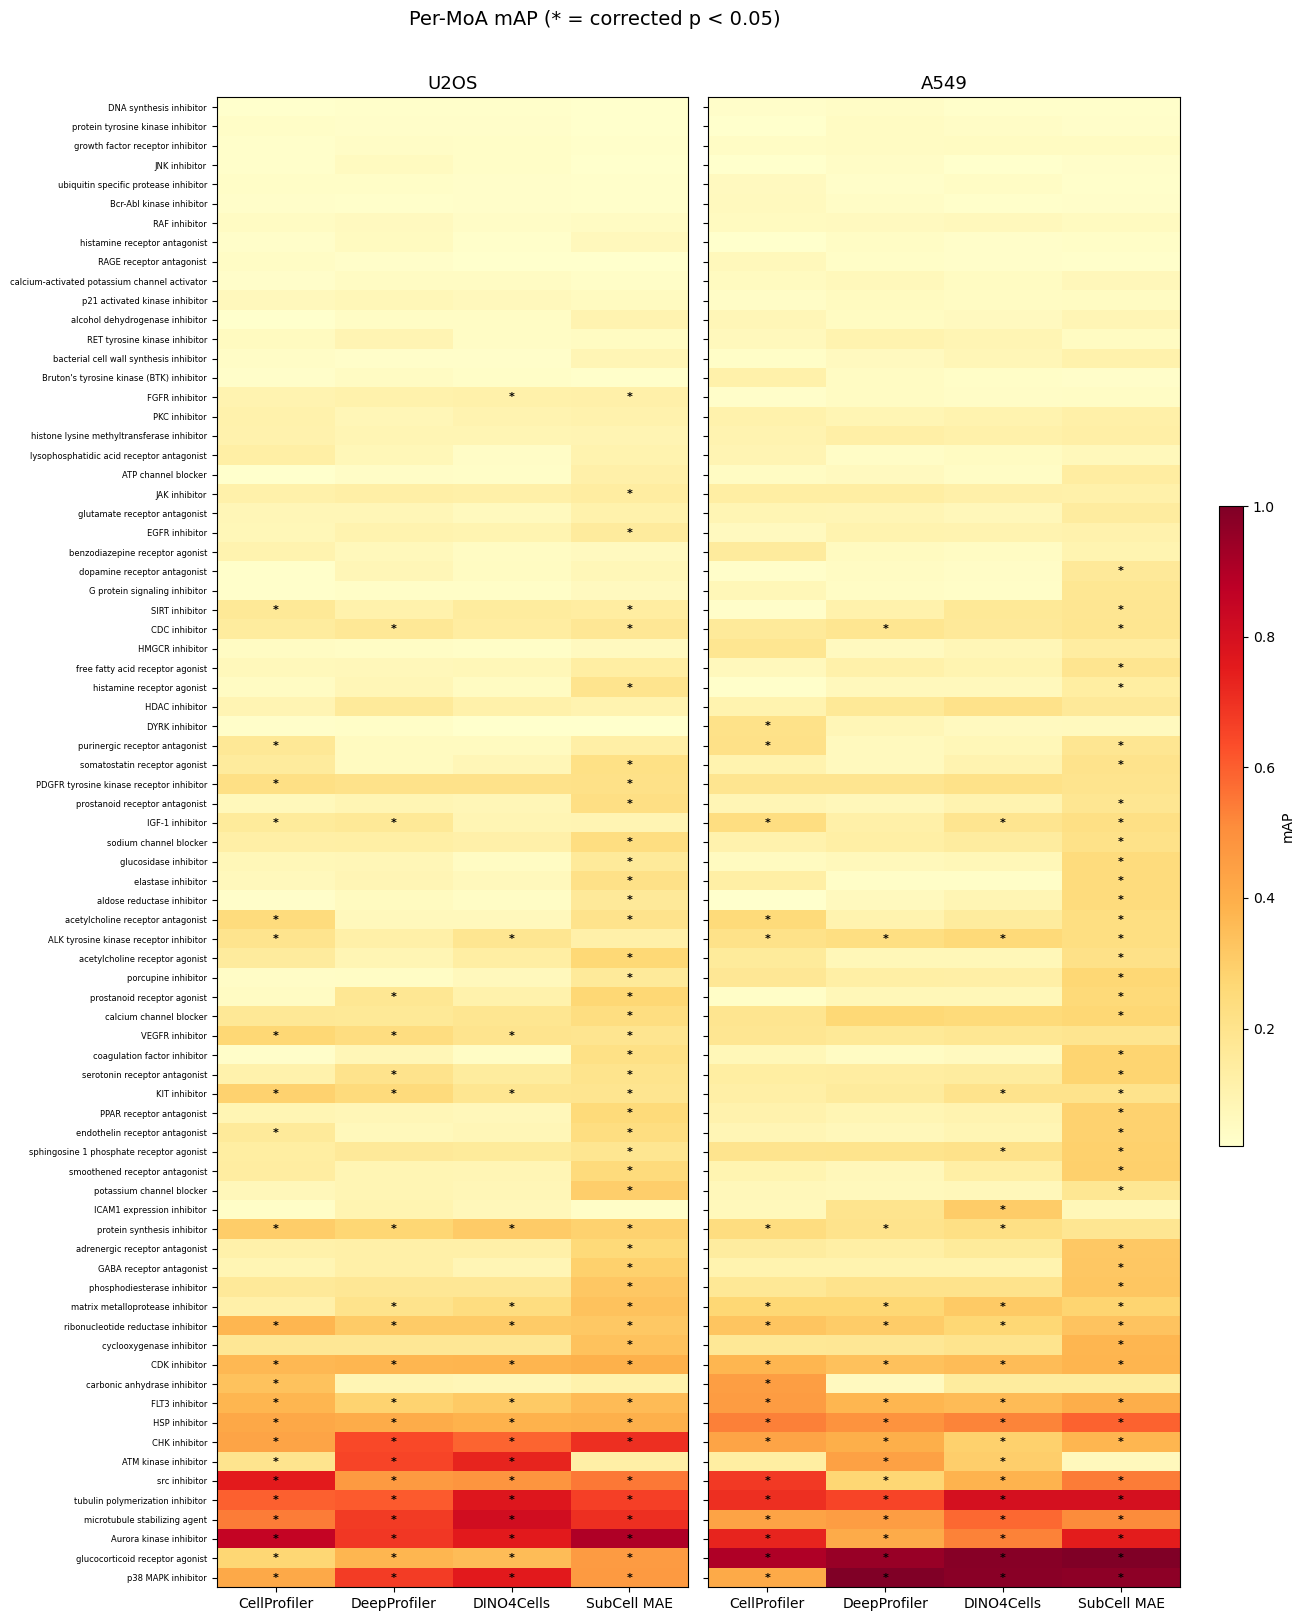

In [5]:
# Build wide tables for both cell types, using a shared MoA order
wide_maps = {}
wide_sigs = {}
for ct in CELL_TYPES:
    frames = []
    sig_frames = []
    for model in MODELS:
        df = moa_data.get((model, ct))
        if df is None:
            continue
        frames.append(df[["moas", "mean_average_precision"]].rename(
            columns={"mean_average_precision": model}))
        sig_frames.append(df[["moas", "below_corrected_p"]].rename(
            columns={"below_corrected_p": model}))
    wide_maps[ct] = reduce(lambda a, b: a.merge(b, on="moas", how="outer"), frames)
    wide_sigs[ct] = reduce(lambda a, b: a.merge(b, on="moas", how="outer"), sig_frames)

# Shared MoA order: sort by max mAP across all models and cell types
model_cols = [m for m in MODELS if m in wide_maps[CELL_TYPES[0]].columns]
combined = wide_maps[CELL_TYPES[0]][["moas"]].copy()
for ct in CELL_TYPES:
    combined = combined.merge(
        wide_maps[ct][["moas"] + model_cols], on="moas", how="outer", suffixes=("", f"_{ct}"))
val_cols = [c for c in combined.columns if c != "moas"]
combined["max_map"] = combined[val_cols].max(axis=1)
moa_order = combined.sort_values("max_map", ascending=True)["moas"].values

# Shared color scale
vmin = min(wide_maps[ct][model_cols].min().min() for ct in CELL_TYPES)
vmax = max(wide_maps[ct][model_cols].max().max() for ct in CELL_TYPES)

fig, axes = plt.subplots(1, 2, figsize=(12, 16))
fig.suptitle("Per-MoA mAP (* = corrected p < 0.05)", fontsize=14, y=1.01)

for col_idx, ct in enumerate(CELL_TYPES):
    ax = axes[col_idx]
    wm = wide_maps[ct].set_index("moas").loc[moa_order].reset_index()
    ws = wide_sigs[ct].set_index("moas").loc[moa_order].reset_index()

    # Verify order matches
    assert list(wm["moas"]) == list(moa_order), f"MoA order mismatch for {ct}"

    mat = wm[model_cols].values
    im = ax.imshow(mat, aspect="auto", cmap="YlOrRd", interpolation="nearest",
                   vmin=vmin, vmax=vmax)

    sig_mat = ws[model_cols].values
    for r in range(sig_mat.shape[0]):
        for c in range(sig_mat.shape[1]):
            if sig_mat[r, c]:
                ax.text(c, r, "*", ha="center", va="center", fontsize=8,
                        color="black", fontweight="bold")

    ax.set_xticks(range(len(model_cols)))
    ax.set_xticklabels([MODEL_LABELS[m] for m in model_cols], fontsize=10)
    ax.set_title(ct, fontsize=13)

    if col_idx == 0:
        ax.set_yticks(range(len(moa_order)))
        ax.set_yticklabels(moa_order, fontsize=6)
    else:
        ax.set_yticks(range(len(moa_order)))
        ax.set_yticklabels([""] * len(moa_order))

cbar_ax = fig.add_axes([1.02, 0.3, 0.02, 0.4])
fig.colorbar(im, cax=cbar_ax, label="mAP")
fig.tight_layout()
fig.savefig("../figures/moa_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Scatter — SubCell MAE vs CellProfiler Per-MoA mAP

Each point is one MoA. Colored by significance in both, one, or neither model.

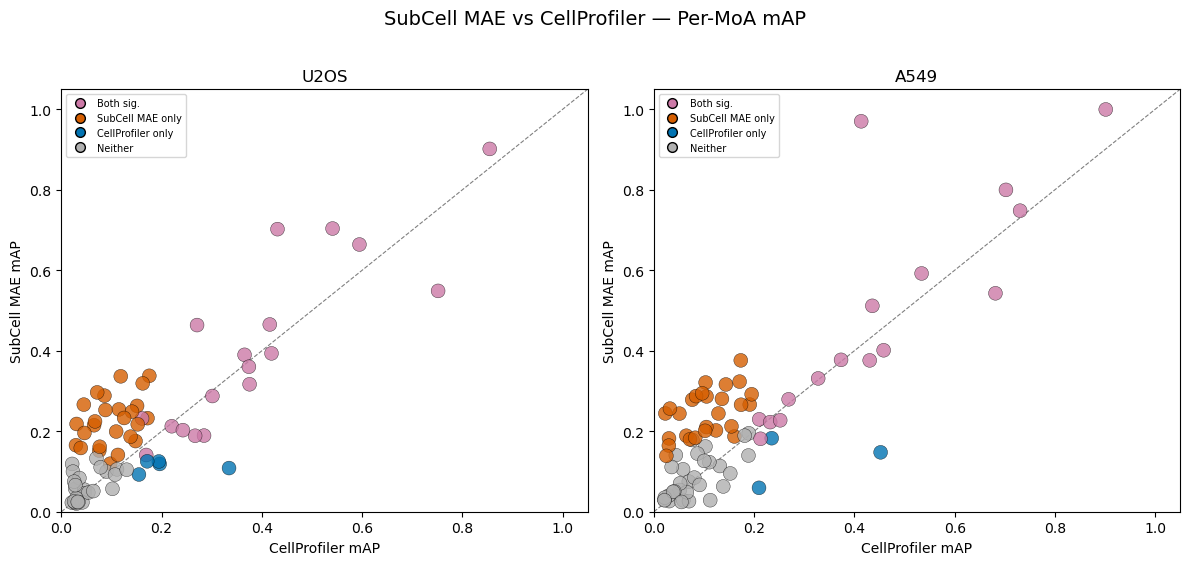

In [6]:
m1, m2 = "cellprofiler", "subcell_mae_masked"

# Shared axis limit across both cell types
all_maps = []
for ct in CELL_TYPES:
    for m in [m1, m2]:
        df = moa_data.get((m, ct))
        if df is not None:
            all_maps.extend(df["mean_average_precision"].values)
shared_lim = [0, max(all_maps) * 1.05]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
fig.suptitle("SubCell MAE vs CellProfiler — Per-MoA mAP", fontsize=14, y=1.02)

for col_idx, ct in enumerate(CELL_TYPES):
    ax = axes[col_idx]
    d1 = moa_data.get((m1, ct))
    d2 = moa_data.get((m2, ct))
    if d1 is None or d2 is None:
        ax.set_visible(False)
        continue

    merged = d1[["moas", "mean_average_precision", "below_corrected_p"]].merge(
        d2[["moas", "mean_average_precision", "below_corrected_p"]],
        on="moas", suffixes=("_cp", "_sc"),
    )

    s_cp = merged["below_corrected_p_cp"].values
    s_sc = merged["below_corrected_p_sc"].values
    colors = np.where(
        s_cp & s_sc, "#cc79a7",              # both: pink/magenta
        np.where(s_sc, MODEL_COLORS[m2],     # subcell only: vermillion
        np.where(s_cp, MODEL_COLORS[m1],     # cellprofiler only: blue
                       "#b0b0b0"))            # neither: gray
    )

    ax.scatter(merged["mean_average_precision_cp"],
               merged["mean_average_precision_sc"],
               c=colors, s=100, edgecolors="k", linewidths=0.3, alpha=0.8)

    ax.plot(shared_lim, shared_lim, "--", color="gray", linewidth=0.8, zorder=0)
    ax.set_xlim(shared_lim)
    ax.set_ylim(shared_lim)
    ax.set_xlabel(f"{MODEL_LABELS[m1]} mAP")
    ax.set_ylabel(f"{MODEL_LABELS[m2]} mAP")
    ax.set_title(ct, fontsize=12)

    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#cc79a7",
               markeredgecolor="k", markersize=7, label="Both sig."),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=MODEL_COLORS[m2],
               markeredgecolor="k", markersize=7, label="SubCell MAE only"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=MODEL_COLORS[m1],
               markeredgecolor="k", markersize=7, label="CellProfiler only"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#b0b0b0",
               markeredgecolor="k", markersize=7, label="Neither"),
    ]
    ax.legend(handles=handles, loc="upper left", fontsize=7)

fig.tight_layout()
fig.savefig("../figures/moa_scatter_subcell_vs_cellprofiler.pdf", dpi=300, bbox_inches="tight")
plt.show()

## MoAs Unique to Each Model

Which MoAs does each model retrieve that no other model does?

In [7]:
for ct in CELL_TYPES:
    print(f"\n{'='*60}")
    print(f"{ct}")
    print(f"{'='*60}")
    sig_sets = {}
    for model in MODELS:
        df = moa_data.get((model, ct))
        if df is not None:
            sig_sets[model] = set(df.loc[df["below_corrected_p"], "moas"])
        else:
            sig_sets[model] = set()

    all_sig = set().union(*sig_sets.values())
    for model in MODELS:
        others = set().union(*(s for m, s in sig_sets.items() if m != model))
        unique = sig_sets[model] - others
        if unique:
            print(f"\n{MODEL_LABELS[model]} only ({len(unique)}):")
            for moa in sorted(unique):
                df = moa_data[(model, ct)]
                row = df[df["moas"] == moa].iloc[0]
                print(f"  - {moa}  (mAP={row['mean_average_precision']:.3f}, "
                      f"p_corr={row['corrected_p_value']:.4f})")

    never = set(moa_data[(MODELS[0], ct)]["moas"]) - all_sig
    print(f"\nNever retrieved by any model: {len(never)}/{len(moa_data[(MODELS[0], ct)])}")


U2OS

CellProfiler only (2):
  - carbonic anhydrase inhibitor  (mAP=0.334, p_corr=0.0010)
  - purinergic receptor antagonist  (mAP=0.171, p_corr=0.0312)

SubCell MAE only (21):
  - EGFR inhibitor  (mAP=0.152, p_corr=0.0075)
  - GABA receptor antagonist  (mAP=0.288, p_corr=0.0004)
  - JAK inhibitor  (mAP=0.141, p_corr=0.0355)
  - PPAR receptor antagonist  (mAP=0.253, p_corr=0.0004)
  - acetylcholine receptor agonist  (mAP=0.263, p_corr=0.0010)
  - adrenergic receptor antagonist  (mAP=0.254, p_corr=0.0004)
  - aldose reductase inhibitor  (mAP=0.165, p_corr=0.0205)
  - calcium channel blocker  (mAP=0.232, p_corr=0.0233)
  - coagulation factor inhibitor  (mAP=0.218, p_corr=0.0050)
  - cyclooxygenase inhibitor  (mAP=0.338, p_corr=0.0004)
  - elastase inhibitor  (mAP=0.215, p_corr=0.0049)
  - glucosidase inhibitor  (mAP=0.161, p_corr=0.0221)
  - histamine receptor agonist  (mAP=0.196, p_corr=0.0096)
  - phosphodiesterase inhibitor  (mAP=0.319, p_corr=0.0004)
  - porcupine inhibitor  (mAP=0.

## Cross-Model Comparison — Per-MoA Bar Plots

4x1 grid (one subplot per model). Only MoAs significant in at least one model are shown.
X-axis order: decreasing mAP as ranked by SubCell MAE (masked). Bars are orange if
significant (corrected p < 0.05), blue otherwise. Thick black outline marks the
best-performing model for each MoA.

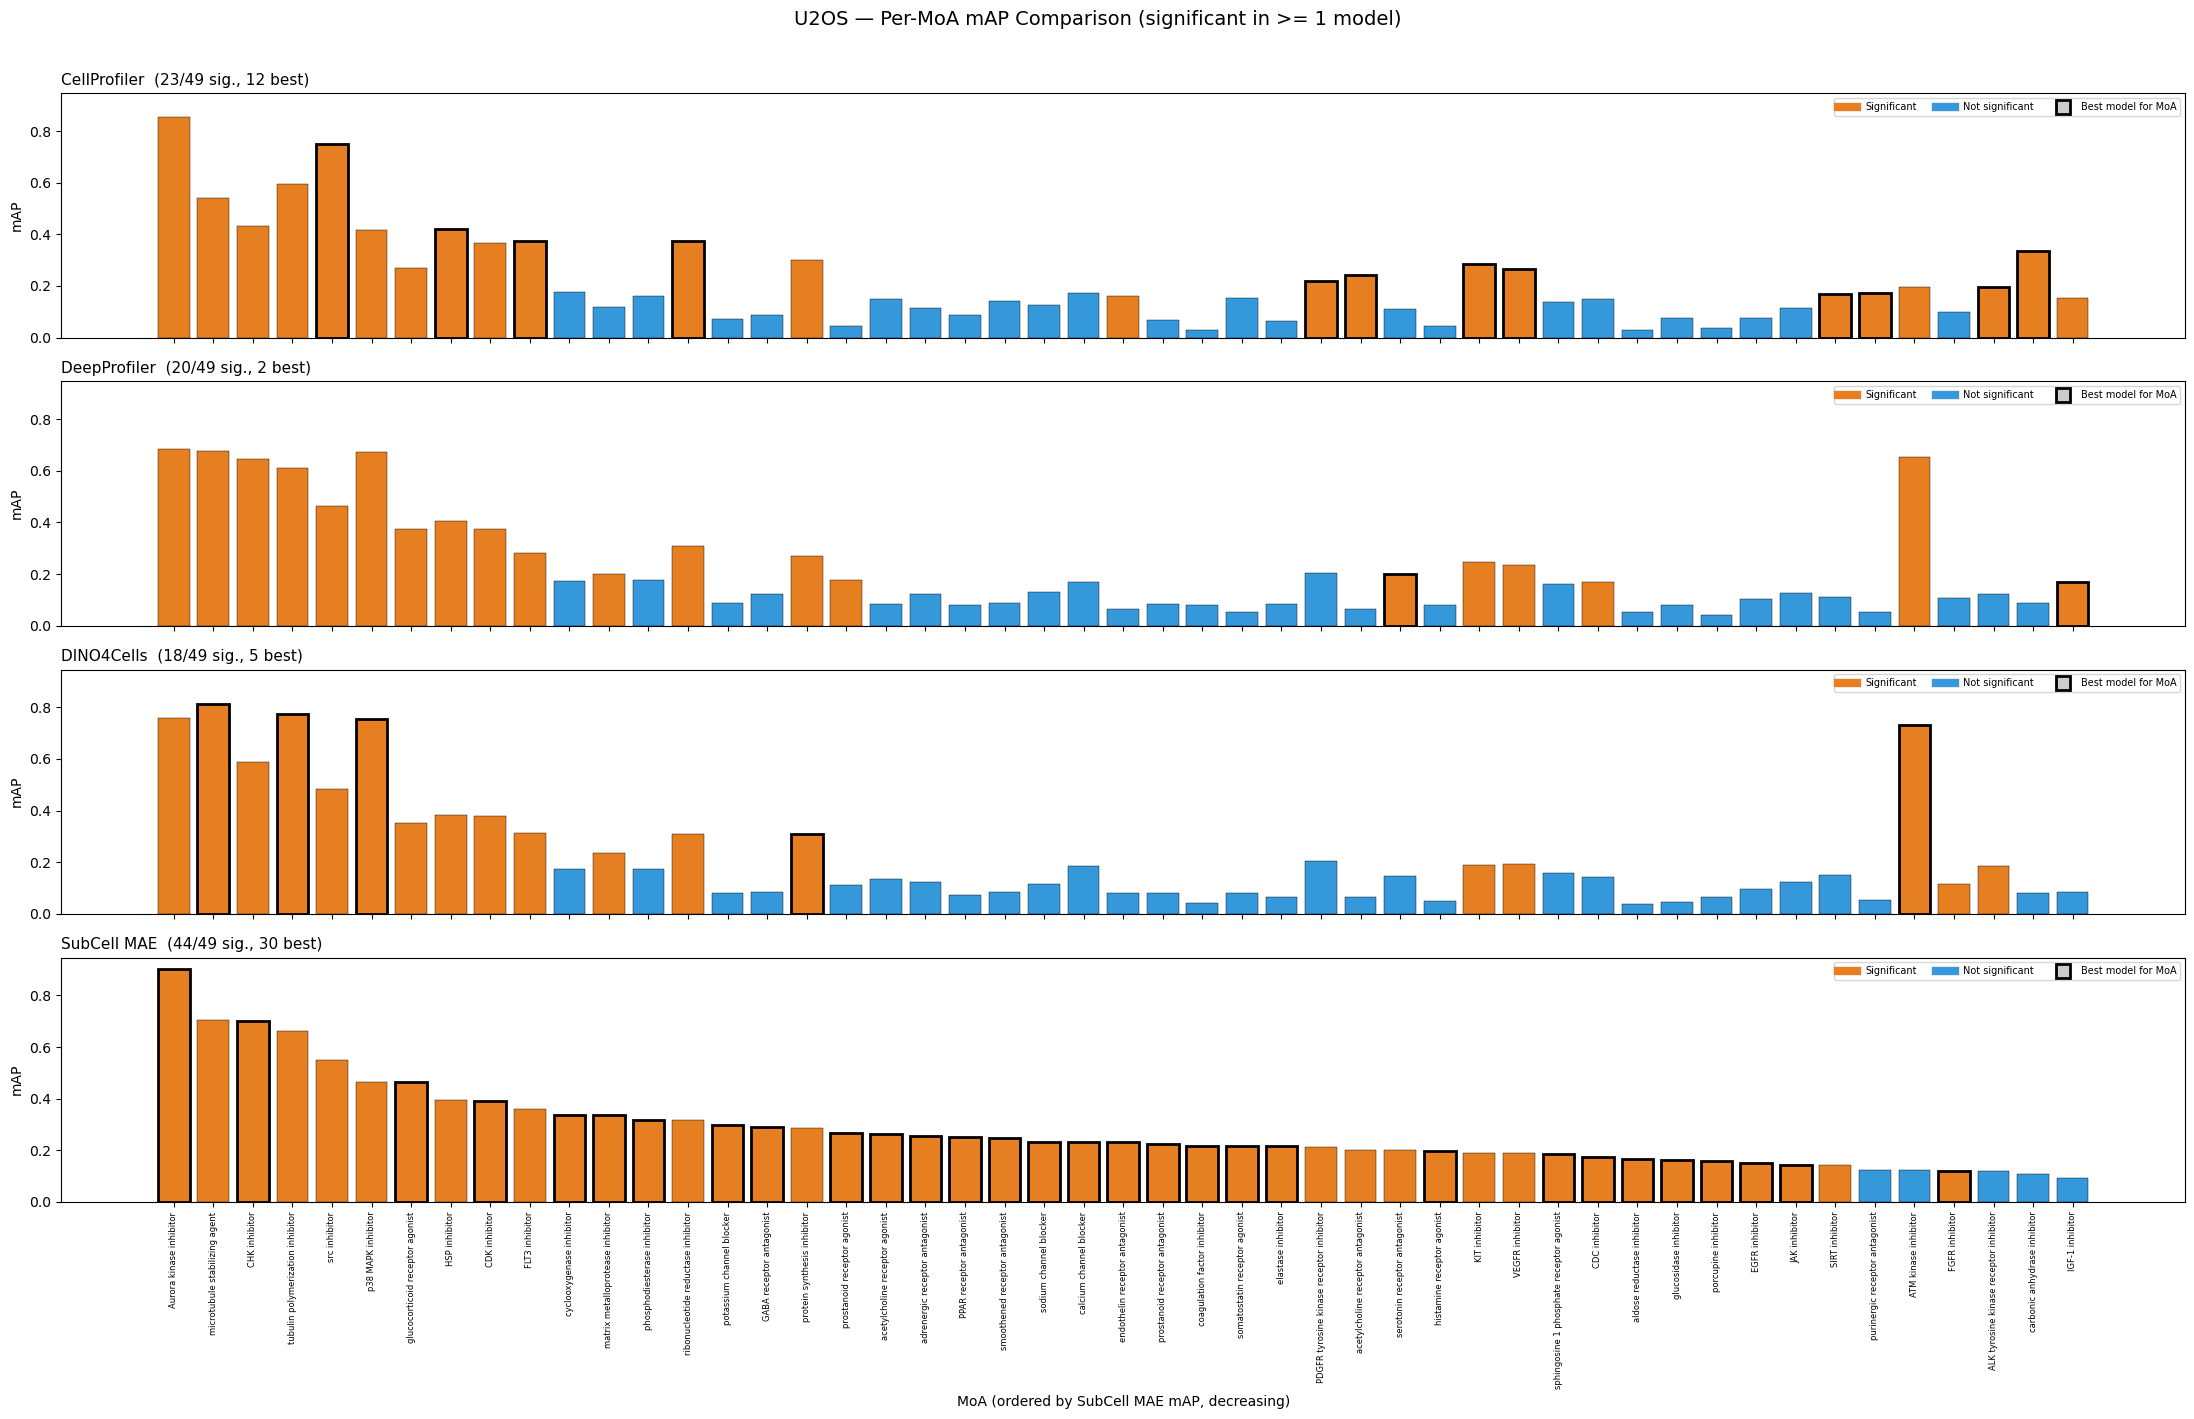

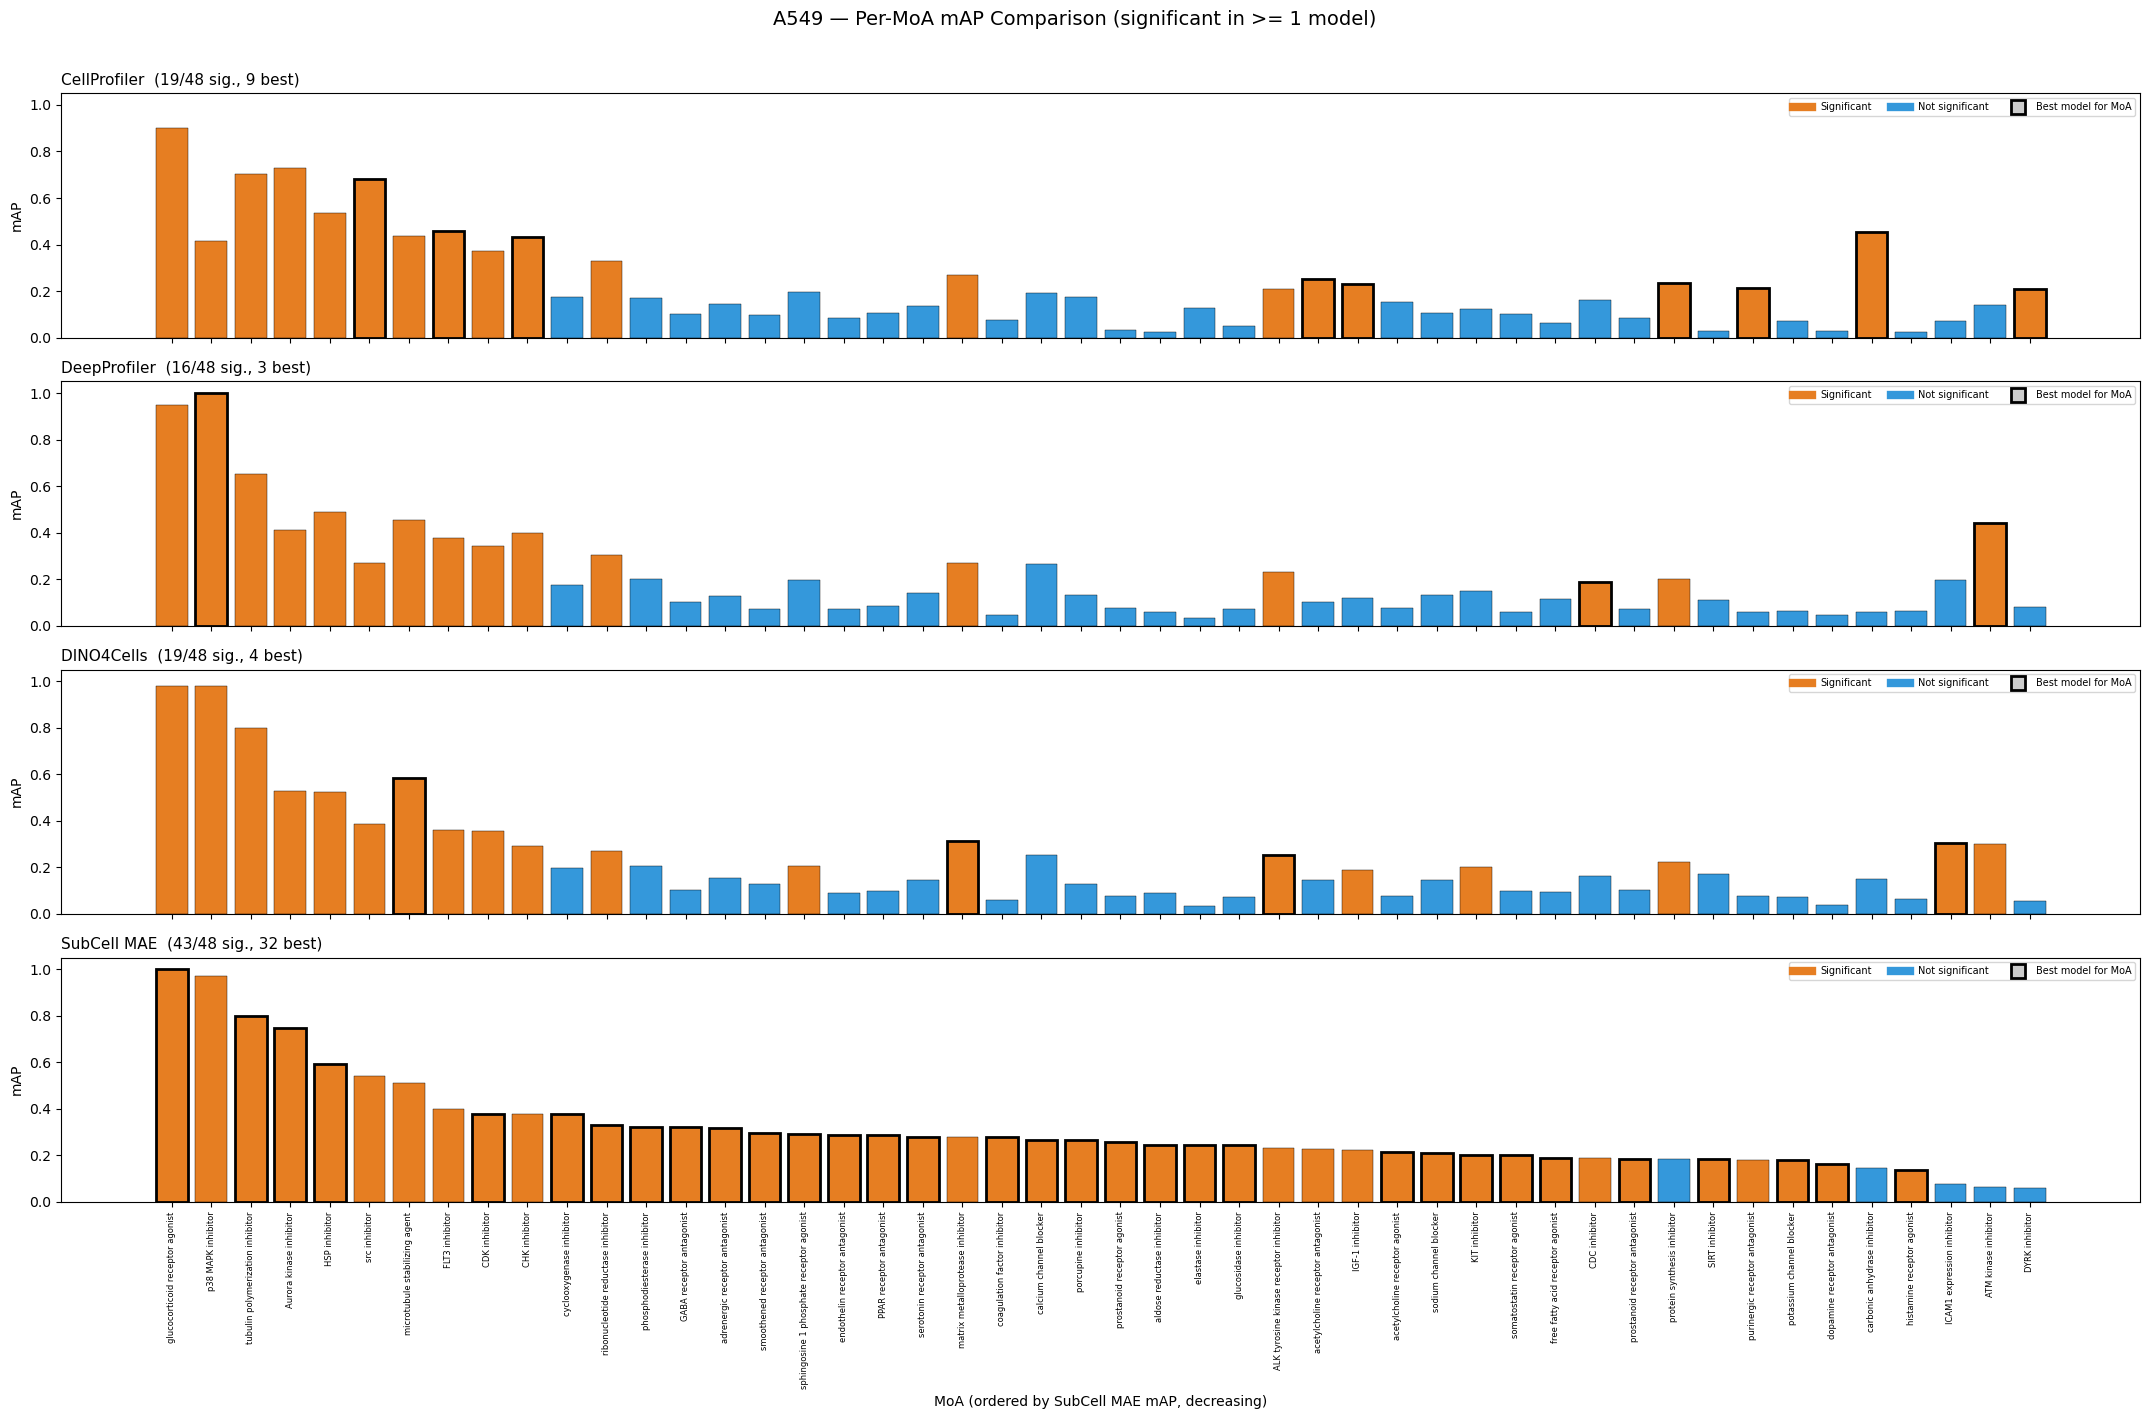

In [8]:
for ct in CELL_TYPES:
    # Build wide mAP and significance tables
    map_dict = {}   # model -> {moa: mAP}
    sig_dict = {}   # model -> {moa: bool}
    for model in MODELS:
        df = moa_data.get((model, ct))
        if df is None:
            continue
        map_dict[model] = dict(zip(df["moas"], df["mean_average_precision"]))
        sig_dict[model] = dict(zip(df["moas"], df["below_corrected_p"]))

    available_models = [m for m in MODELS if m in map_dict]
    all_moas = set()
    for m in available_models:
        all_moas |= set(map_dict[m].keys())

    # Filter to MoAs significant in at least one model
    sig_moas = set()
    for moa in all_moas:
        if any(sig_dict[m].get(moa, False) for m in available_models):
            sig_moas.add(moa)
    sig_moas = list(sig_moas)

    # Sort by SubCell MAE masked mAP (decreasing left to right)
    ref = map_dict.get("subcell_mae_masked", {})
    sig_moas.sort(key=lambda moa: ref.get(moa, 0), reverse=True)

    # Determine best model per MoA
    best_model = {}
    for moa in sig_moas:
        scores = {m: map_dict[m].get(moa, np.nan) for m in available_models}
        best_model[moa] = max(scores, key=lambda m: scores[m])

    # Shared y-axis limit across all subplots
    y_max = 0
    for m in available_models:
        for moa in sig_moas:
            y_max = max(y_max, map_dict[m].get(moa, 0))
    y_max *= 1.05

    # Plot
    x = np.arange(len(sig_moas))
    fig, axes = plt.subplots(len(available_models), 1,
                             figsize=(max(len(sig_moas) * 0.45, 14), 3.5 * len(available_models)),
                             sharex=True, sharey=True)
    fig.suptitle(f"{ct} — Per-MoA mAP Comparison (significant in >= 1 model)", fontsize=14, y=1.01)

    for i, model in enumerate(available_models):
        ax = axes[i]
        heights = [map_dict[model].get(moa, 0) for moa in sig_moas]
        is_sig = [sig_dict[model].get(moa, False) for moa in sig_moas]
        is_best = [best_model[moa] == model for moa in sig_moas]

        face_colors = ["#e67e22" if s else "#3498db" for s in is_sig]
        edge_colors = ["black"] * len(sig_moas)
        linewidths = [2.0 if b else 0.3 for b in is_best]

        ax.bar(x, heights, color=face_colors, edgecolor=edge_colors,
               linewidth=linewidths, width=0.8)
        ax.set_ylabel("mAP", fontsize=10)
        ax.set_ylim(0, y_max)
        n_sig = sum(is_sig)
        n_best = sum(is_best)
        ax.set_title(f"{MODEL_LABELS[model]}  ({n_sig}/{len(sig_moas)} sig., {n_best} best)",
                     fontsize=11, loc="left")

        handles = [
            Line2D([0], [0], color="#e67e22", lw=6, label="Significant"),
            Line2D([0], [0], color="#3498db", lw=6, label="Not significant"),
            Line2D([0], [0], marker="s", color="w", markerfacecolor="#cccccc",
                   markeredgecolor="black", markeredgewidth=2.0, markersize=10,
                   label="Best model for MoA"),
        ]
        ax.legend(handles=handles, loc="upper right", fontsize=7, ncol=3)

    # X-axis labels on bottom subplot only
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(sig_moas, rotation=90, fontsize=6, ha="center")
    axes[-1].set_xlabel("MoA (ordered by SubCell MAE mAP, decreasing)", fontsize=10)

    fig.tight_layout()
    fig.savefig(f"../figures/moa_crossmodel_bars_{ct}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

## Grouped Bar Plot — Per-MoA mAP Across Models

Single plot per cell type. Grouped bars (one per model) for each MoA, colored by model.
Star above bar if significant (corrected p < 0.05). Only MoAs significant in at least
one of the plotted models are shown. Change `PLOT_MODELS` to control which models appear.

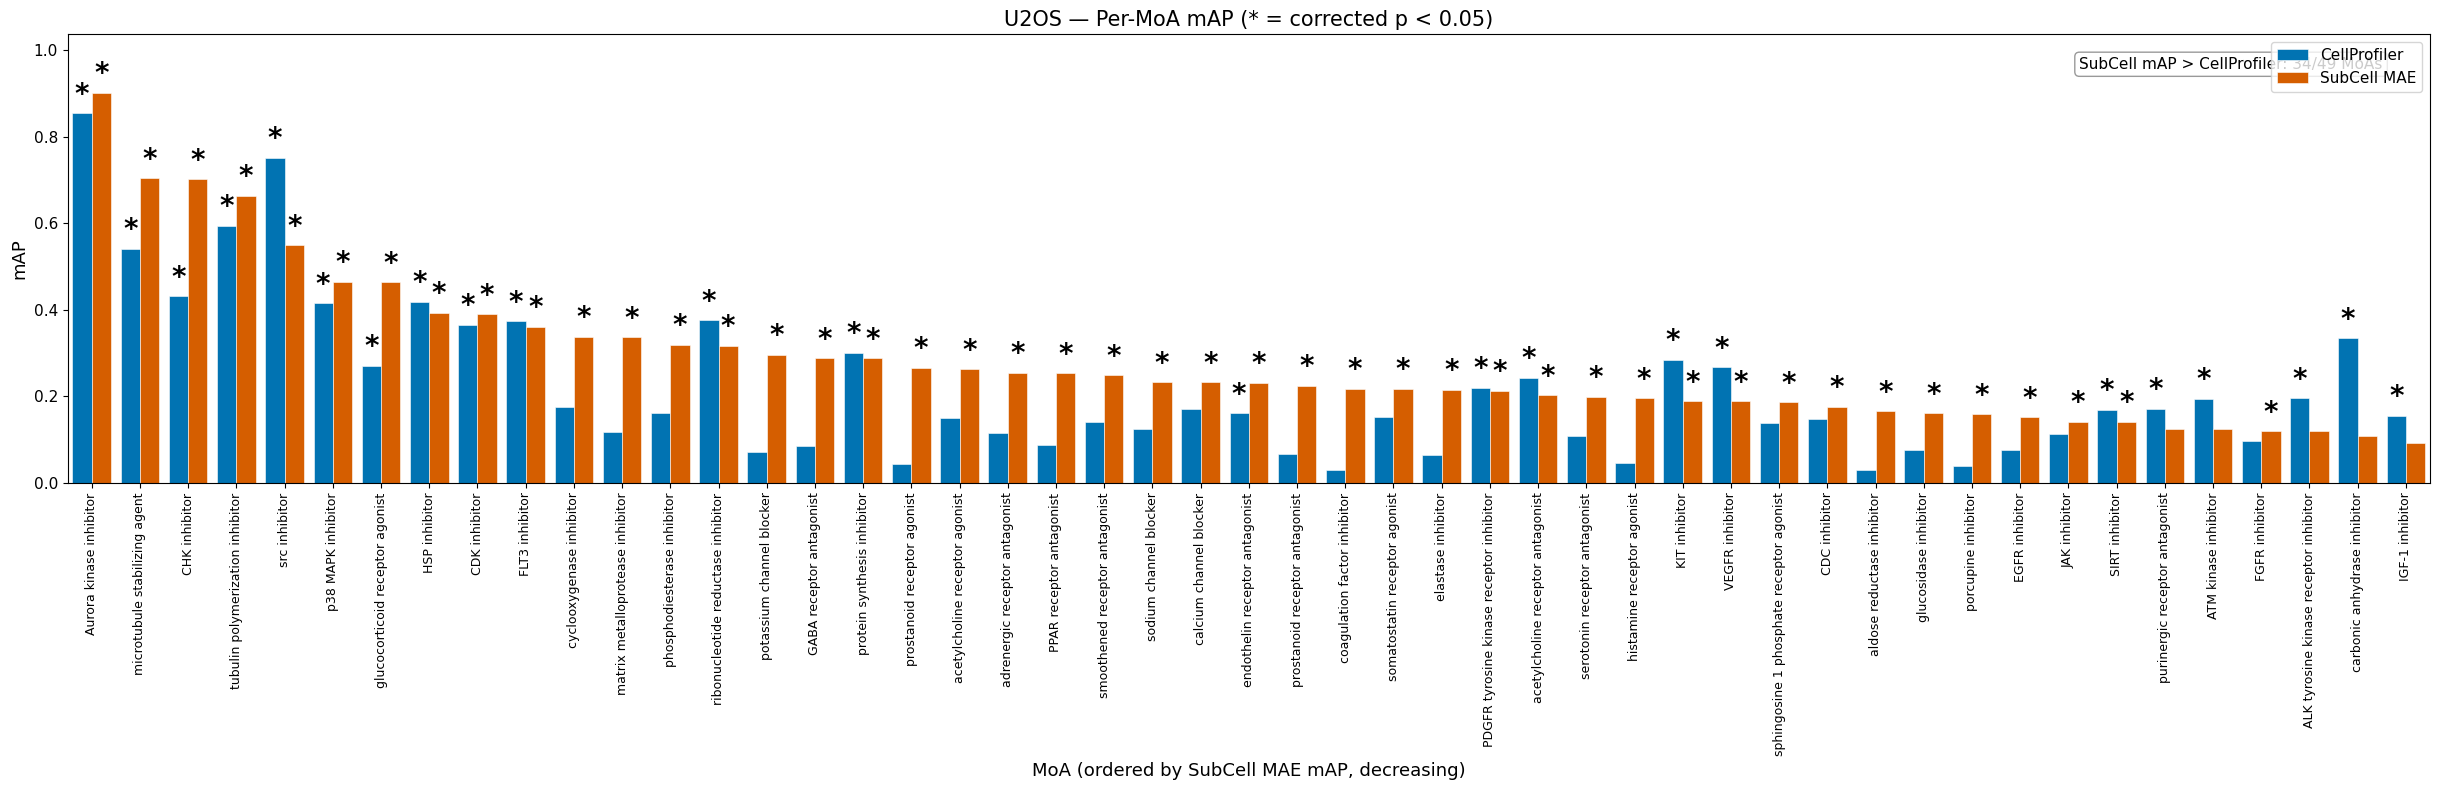

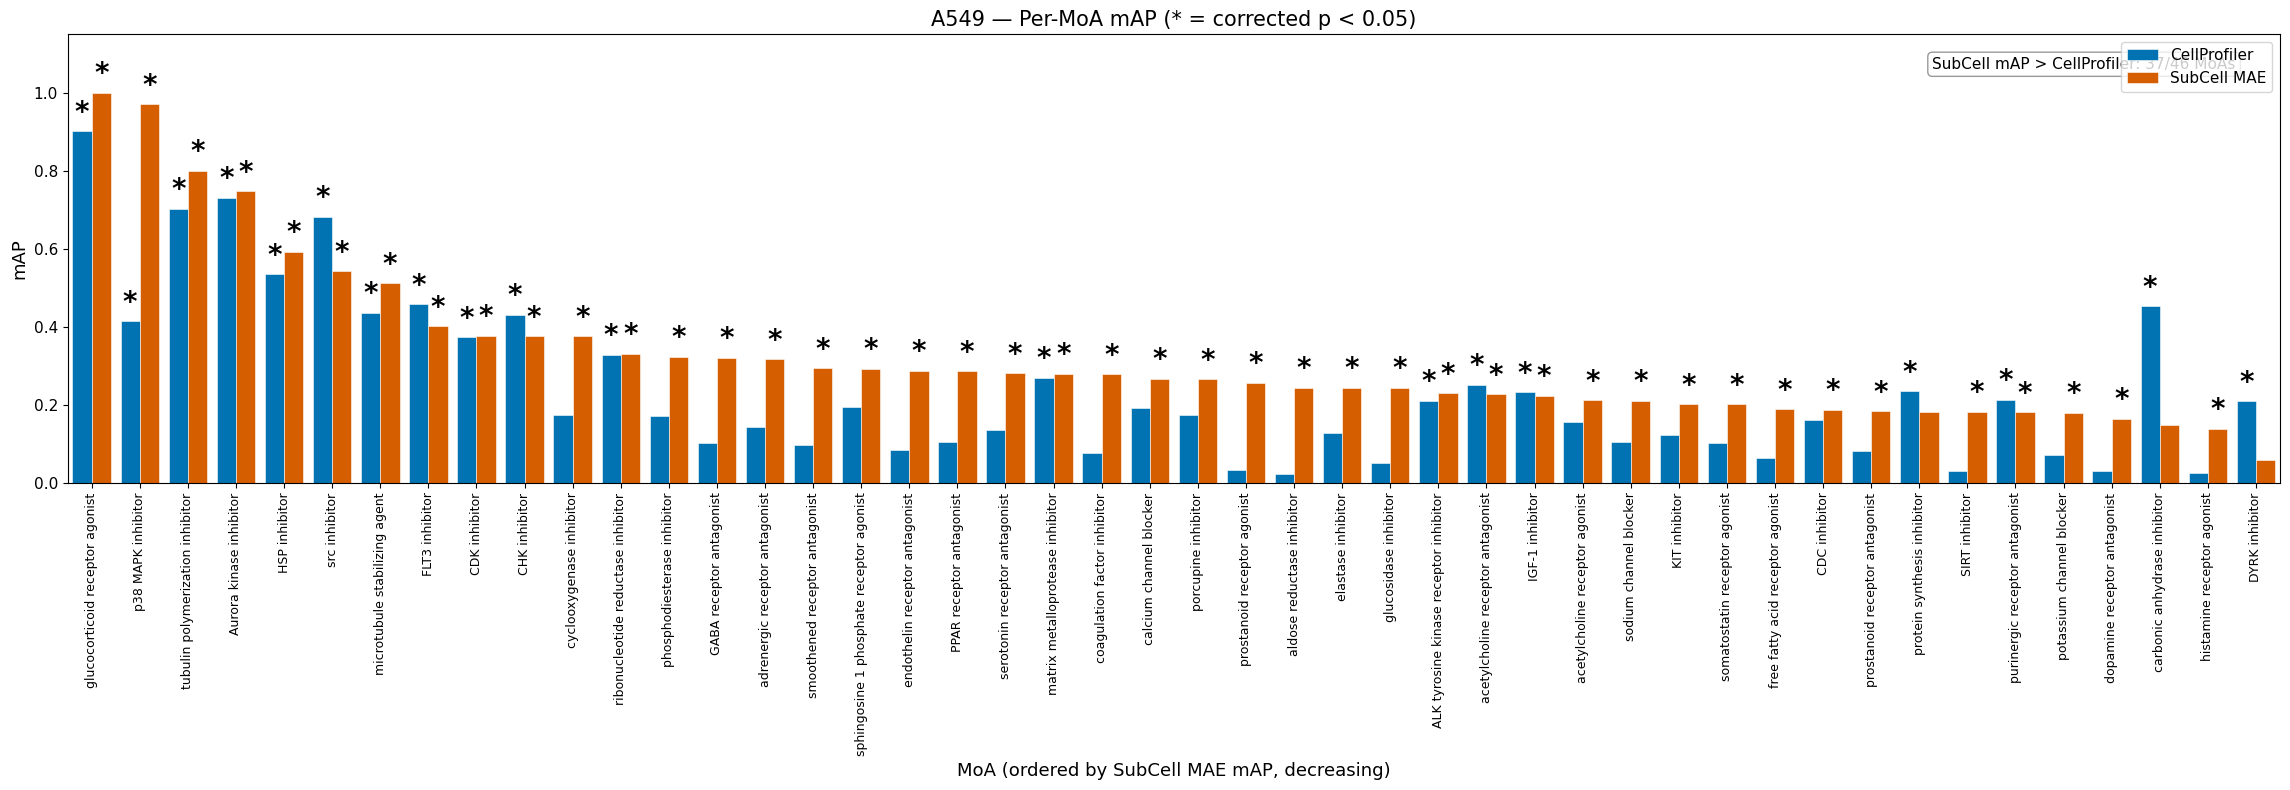

In [9]:
# Change this list to control which models appear in the grouped bar plot
PLOT_MODELS = ["cellprofiler", "subcell_mae_masked"]

for ct in CELL_TYPES:
    # Build lookup dicts for the selected models
    map_dict = {}
    sig_dict = {}
    available = []
    for model in PLOT_MODELS:
        df = moa_data.get((model, ct))
        if df is None:
            continue
        available.append(model)
        map_dict[model] = dict(zip(df["moas"], df["mean_average_precision"]))
        sig_dict[model] = dict(zip(df["moas"], df["below_corrected_p"]))

    all_moas = set()
    for m in available:
        all_moas |= set(map_dict[m].keys())

    # Filter to MoAs significant in at least one plotted model
    sig_moas = [moa for moa in all_moas
                if any(sig_dict[m].get(moa, False) for m in available)]

    # Sort by subcell_mae_masked mAP (decreasing)
    ref = map_dict.get("subcell_mae_masked", {})
    sig_moas.sort(key=lambda moa: ref.get(moa, 0), reverse=True)

    n_models = len(available)
    n_moas = len(sig_moas)
    bar_width = 0.8 / n_models
    x = np.arange(n_moas)

    # Shared y limit
    y_max = max(map_dict[m].get(moa, 0)
                for m in available for moa in sig_moas) * 1.15

    fig, ax = plt.subplots(figsize=(n_moas * 0.5, 8))

    for j, model in enumerate(available):
        offsets = x + (j - (n_models - 1) / 2) * bar_width
        heights = [map_dict[model].get(moa, 0) for moa in sig_moas]
        is_sig = [sig_dict[model].get(moa, False) for moa in sig_moas]

        ax.bar(offsets, heights, width=bar_width, color=MODEL_COLORS[model],
               edgecolor="white", linewidth=0.4, label=MODEL_LABELS[model])

        # Stars above significant bars
        for k, (off, h, sig) in enumerate(zip(offsets, heights, is_sig)):
            if sig:
                ax.text(off, h + y_max * 0.01, "*", ha="center", va="bottom",
                        fontsize=20, fontweight="bold", color="black")

    # Fraction of MoAs where SubCell beats CellProfiler
    n_subcell_wins = sum(
        map_dict["subcell_mae_masked"].get(moa, 0) > map_dict["cellprofiler"].get(moa, 0)
        for moa in sig_moas
    )
    ax.text(0.98, 0.95,
            f"SubCell mAP > CellProfiler: {n_subcell_wins}/{n_moas} MoAs",
            transform=ax.transAxes, ha="right", va="top", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8))

    ax.set_ylim(0, y_max)
    ax.set_xlim(-0.5, n_moas - 0.5)
    ax.set_ylabel("mAP", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(sig_moas, rotation=90, fontsize=9, ha="center")
    ax.set_xlabel("MoA (ordered by SubCell MAE mAP, decreasing)", fontsize=13)
    ax.set_title(f"{ct} — Per-MoA mAP (* = corrected p < 0.05)", fontsize=15)
    ax.legend(fontsize=11, loc="upper right")
    ax.tick_params(axis="y", labelsize=11)

    fig.tight_layout()
    fig.savefig(f"../figures/moa_grouped_bars_{ct}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [10]:
df

,moas,mean_average_precision,p_value,corrected_p_value,below_p,below_corrected_p
0,ALK tyrosine kinase receptor inhibitor,0.229590,0.003600,0.009899,True,True
1,ATM kinase inhibitor,0.062778,0.243676,0.312717,False,False
2,ATP channel blocker,0.140668,0.042796,0.070112,True,False
3,Aurora kinase inhibitor,0.747833,0.000100,0.000550,True,True
4,Bcr-Abl kinase inhibitor,0.028394,0.997200,0.998900,False,False
...,...,...,...,...,...,...
72,somatostatin receptor agonist,0.200987,0.010699,0.023098,True,True
73,sphingosine 1 phosphate receptor agonist,0.291859,0.000100,0.000550,True,True
74,src inhibitor,0.542721,0.000100,0.000550,True,True
75,tubulin polymerization inhibitor,0.799598,0.000100,0.000550,True,True
